# P05: Análisis Exploratorio de Datos — GTZAN
**Autores:** Pablo Blanes, Vicent Granero, Alejandro Coscolín, Alex Payá  
**Asignatura:** Inteligencia Artificial — EPSA (UPV)

Este notebook genera **todas las figuras** del análisis exploratorio. Ejecuta cada celda en orden. Necesitas el archivo `features_3_sec.csv` del dataset GTZAN en la misma carpeta (o ajusta `CSV_PATH`).

## 0. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Ajusta esta ruta si el CSV está en otro lugar
CSV_PATH = 'features_3_sec.csv'

# Estilo global de plots
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='darkgrid', palette='muted')

GENEROS = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']
PALETTE = sns.color_palette('tab10', 10)
GENRE_COLOR = dict(zip(GENEROS, PALETTE))

print('Librerías cargadas correctamente ✓')

## 1. Carga y preparación de datos

In [11]:
# ── Cargar CSV completo (fragmentos de 3 segundos)
df_raw = pd.read_csv(CSV_PATH)
print(f'Dataset completo: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas')
print(f'Columnas: {list(df_raw.columns[:6])} ...')

# Renombrar etiqueta si se llama 'label' o 'genre'
label_col = 'label' if 'label' in df_raw.columns else 'genre'
df_raw = df_raw.rename(columns={label_col: 'genre'})

# Eliminar columna 'filename' si existe
if 'filename' in df_raw.columns:
    df_raw = df_raw.drop(columns=['filename'])

# Extraer características numéricas (todas excepto 'genre')
feat_cols = [c for c in df_raw.columns if c != 'genre']
print(f'\nCaracterísticas numéricas: {len(feat_cols)}')

# ── Agrupar por canción completa (media de sus ~10 fragmentos)
# El nombre de canción está codificado en el índice o en 'filename'
# Usamos la propia agrupación por género + bloque de 10 filas
df_raw['song_id'] = df_raw.groupby('genre').cumcount() // 10
df_songs = df_raw.groupby(['genre', 'song_id'])[feat_cols].mean().reset_index()
df_songs = df_songs.drop(columns=['song_id'])
print(f'\nDataset agrupado por canción: {df_songs.shape[0]} canciones')
print(df_songs['genre'].value_counts())

Dataset completo: 9990 filas × 60 columnas
Columnas: ['filename', 'length', 'chroma_stft_mean', 'chroma_stft_var', 'rms_mean', 'rms_var'] ...

Características numéricas: 58

Dataset agrupado por canción: 1000 canciones
genre
blues        100
classical    100
country      100
disco        100
hiphop       100
jazz         100
metal        100
pop          100
reggae       100
rock         100
Name: count, dtype: int64


---
## 2. Análisis Univariante
### 2.1 Distribución de géneros

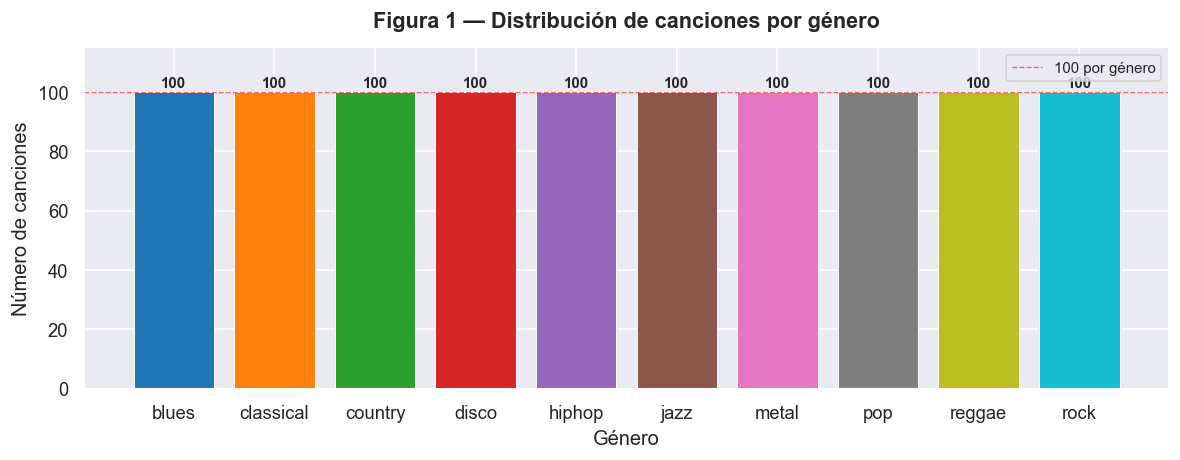

✓ Figura 1 guardada


In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
counts = df_songs['genre'].value_counts().reindex(GENEROS)
bars = ax.bar(counts.index, counts.values,
              color=[GENRE_COLOR[g] for g in counts.index], edgecolor='white', linewidth=0.6)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v),
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Figura 1 — Distribución de canciones por género', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Género'); ax.set_ylabel('Número de canciones')
ax.set_ylim(0, 115)
ax.axhline(100, color='red', linestyle='--', linewidth=0.8, alpha=0.6, label='100 por género')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig01_distribucion_generos.png', bbox_inches='tight')
plt.show()
print('✓ Figura 1 guardada')

### 2.2 Estadísticas descriptivas de las características principales

In [4]:
key_feats = ['tempo', 'rms_mean', 'spectral_centroid_mean', 
             'spectral_bandwidth_mean', 'zero_crossing_rate_mean', 'mfcc1_mean']

# Ajuste de nombres según el CSV real del GTZAN
# Mapeamos los nombres posibles
name_map = {
    'rms_mean':                  next((c for c in feat_cols if 'rms' in c.lower() and 'mean' in c.lower()), None),
    'spectral_centroid_mean':    next((c for c in feat_cols if 'centroid' in c.lower() and 'mean' in c.lower()), None),
    'spectral_bandwidth_mean':   next((c for c in feat_cols if 'bandwidth' in c.lower() and 'mean' in c.lower()), None),
    'zero_crossing_rate_mean':   next((c for c in feat_cols if 'zero' in c.lower() and 'mean' in c.lower()), None),
    'mfcc1_mean':                next((c for c in feat_cols if 'mfcc1_mean' in c.lower() or 'mfcc_1_mean' in c.lower()), None),
    'tempo':                     next((c for c in feat_cols if 'tempo' in c.lower()), None),
}

available = {k: v for k, v in name_map.items() if v is not None}
print('Columnas mapeadas:', available)

stats_df = df_songs[[v for v in available.values()]].describe().round(4)
stats_df.index.name = 'Estadístico'
print('\nEstadísticas descriptivas de características clave:')
display(stats_df)

Columnas mapeadas: {'rms_mean': 'rms_mean', 'spectral_centroid_mean': 'spectral_centroid_mean', 'spectral_bandwidth_mean': 'spectral_bandwidth_mean', 'zero_crossing_rate_mean': 'zero_crossing_rate_mean', 'mfcc1_mean': 'mfcc1_mean', 'tempo': 'tempo'}

Estadísticas descriptivas de características clave:


,rms_mean,spectral_centroid_mean,spectral_bandwidth_mean,zero_crossing_rate_mean,mfcc1_mean,tempo
Estadístico,,,,,,
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,0.1309,2198.9588,2241.1596,0.1026,-145.4492,124.8829
std,0.0648,701.9359,518.4812,0.0404,99.4036,16.0740
min,0.0054,569.3757,970.3287,0.0215,-545.8936,79.0025
25%,0.0869,1636.3569,1905.7308,0.0709,-199.1608,113.4483
50%,0.1229,2207.2049,2222.4336,0.0984,-121.6460,123.7191
75%,0.1733,2680.9779,2579.3669,0.1299,-75.2019,133.6458
max,0.3977,4433.8680,3508.4144,0.2721,42.3417,184.5703


### 2.3 Histogramas de las características principales

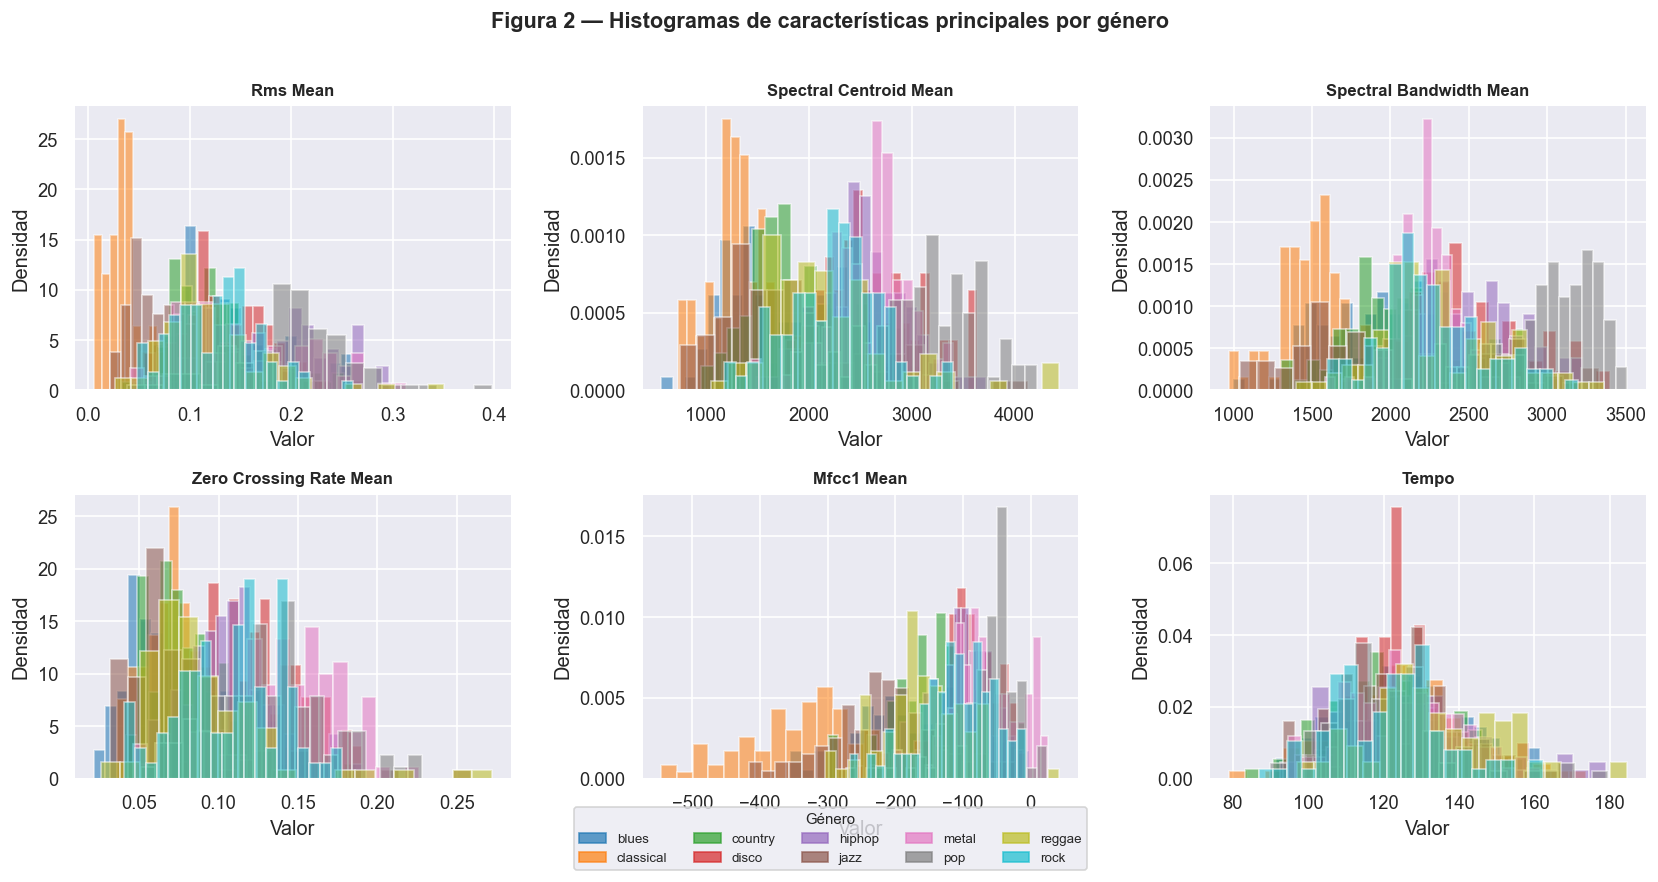

✓ Figura 2 guardada


In [5]:
selected = [v for v in available.values() if v]  # características disponibles
labels_nice = list(available.keys())

n = len(selected)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(selected, labels_nice)):
    ax = axes[i]
    for genre in GENEROS:
        subset = df_songs[df_songs['genre'] == genre][col]
        ax.hist(subset, bins=20, alpha=0.55, color=GENRE_COLOR[genre], label=genre, density=True)
    ax.set_title(label.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Valor'); ax.set_ylabel('Densidad')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# Leyenda global
handles = [plt.Rectangle((0,0),1,1, color=GENRE_COLOR[g], alpha=0.7) for g in GENEROS]
fig.legend(handles, GENEROS, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02), title='Género', title_fontsize=9)

fig.suptitle('Figura 2 — Histogramas de características principales por género',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig02_histogramas.png', bbox_inches='tight')
plt.show()
print('✓ Figura 2 guardada')

### 2.4 Boxplots por género

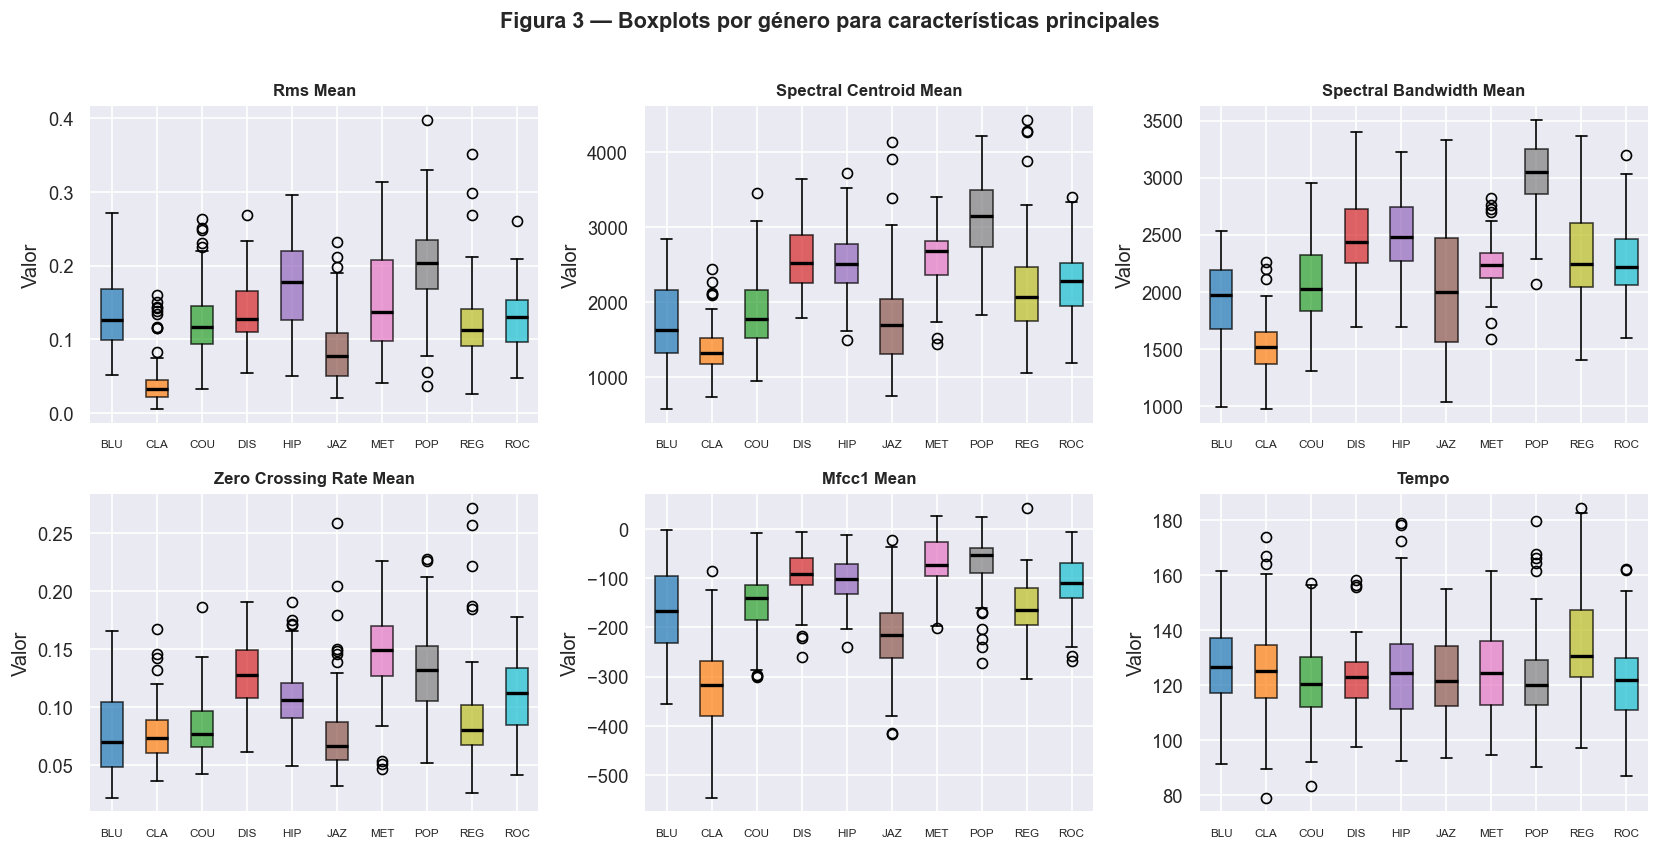

✓ Figura 3 guardada


In [6]:
fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(selected, labels_nice)):
    ax = axes[i]
    data_by_genre = [df_songs[df_songs['genre'] == g][col].values for g in GENEROS]
    bp = ax.boxplot(data_by_genre, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels([g[:3].upper() for g in GENEROS], fontsize=7)
    ax.set_title(label.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Valor')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Figura 3 — Boxplots por género para características principales',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig03_boxplots.png', bbox_inches='tight')
plt.show()
print('✓ Figura 3 guardada')

### 2.5 Distribución del Tempo (distribución bimodal)

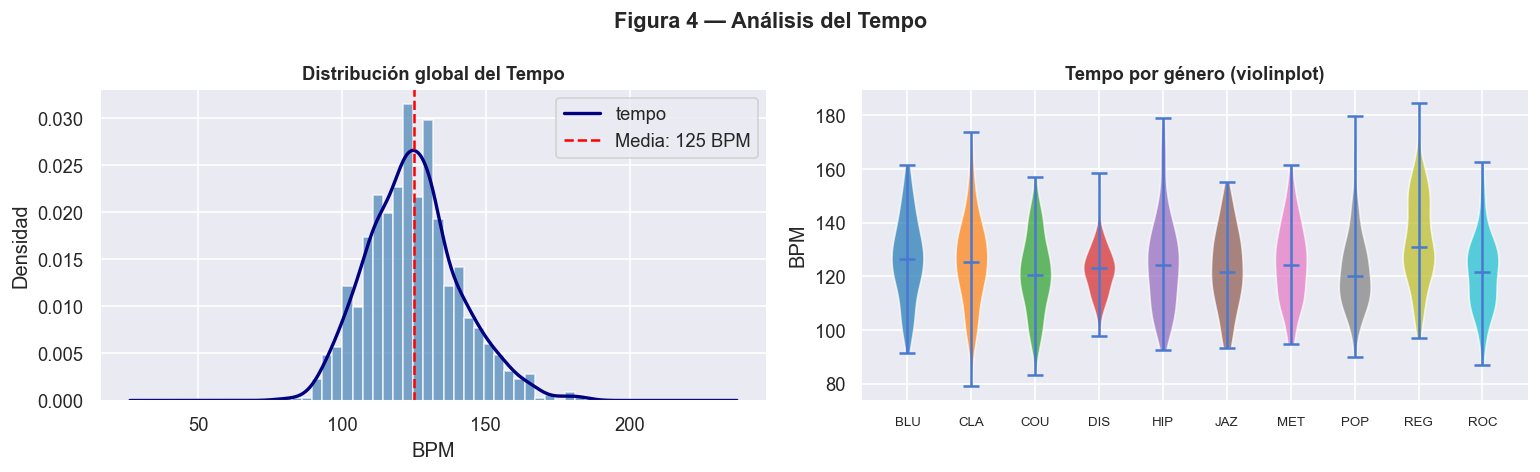

✓ Figura 4 guardada


In [7]:
tempo_col = available.get('tempo')
if tempo_col:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histograma global con KDE
    ax = axes[0]
    ax.hist(df_songs[tempo_col], bins=30, color='steelblue', alpha=0.7, density=True, edgecolor='white')
    df_songs[tempo_col].plot.kde(ax=ax, color='navy', linewidth=2)
    ax.set_title('Distribución global del Tempo', fontsize=11, fontweight='bold')
    ax.set_xlabel('BPM'); ax.set_ylabel('Densidad')
    ax.axvline(df_songs[tempo_col].mean(), color='red', linestyle='--', label=f'Media: {df_songs[tempo_col].mean():.0f} BPM')
    ax.legend()

    # Violinplot por género
    ax2 = axes[1]
    data_by_genre = [df_songs[df_songs['genre'] == g][tempo_col].values for g in GENEROS]
    parts = ax2.violinplot(data_by_genre, showmedians=True)
    for pc, color in zip(parts['bodies'], PALETTE):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    ax2.set_xticks(range(1, 11))
    ax2.set_xticklabels([g[:3].upper() for g in GENEROS], fontsize=8)
    ax2.set_title('Tempo por género (violinplot)', fontsize=11, fontweight='bold')
    ax2.set_ylabel('BPM')

    fig.suptitle('Figura 4 — Análisis del Tempo', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig04_tempo.png', bbox_inches='tight')
    plt.show()
    print('✓ Figura 4 guardada')
else:
    print('⚠ Columna tempo no encontrada')

---
## 3. Análisis Multivariante
### 3.1 Matriz de correlación

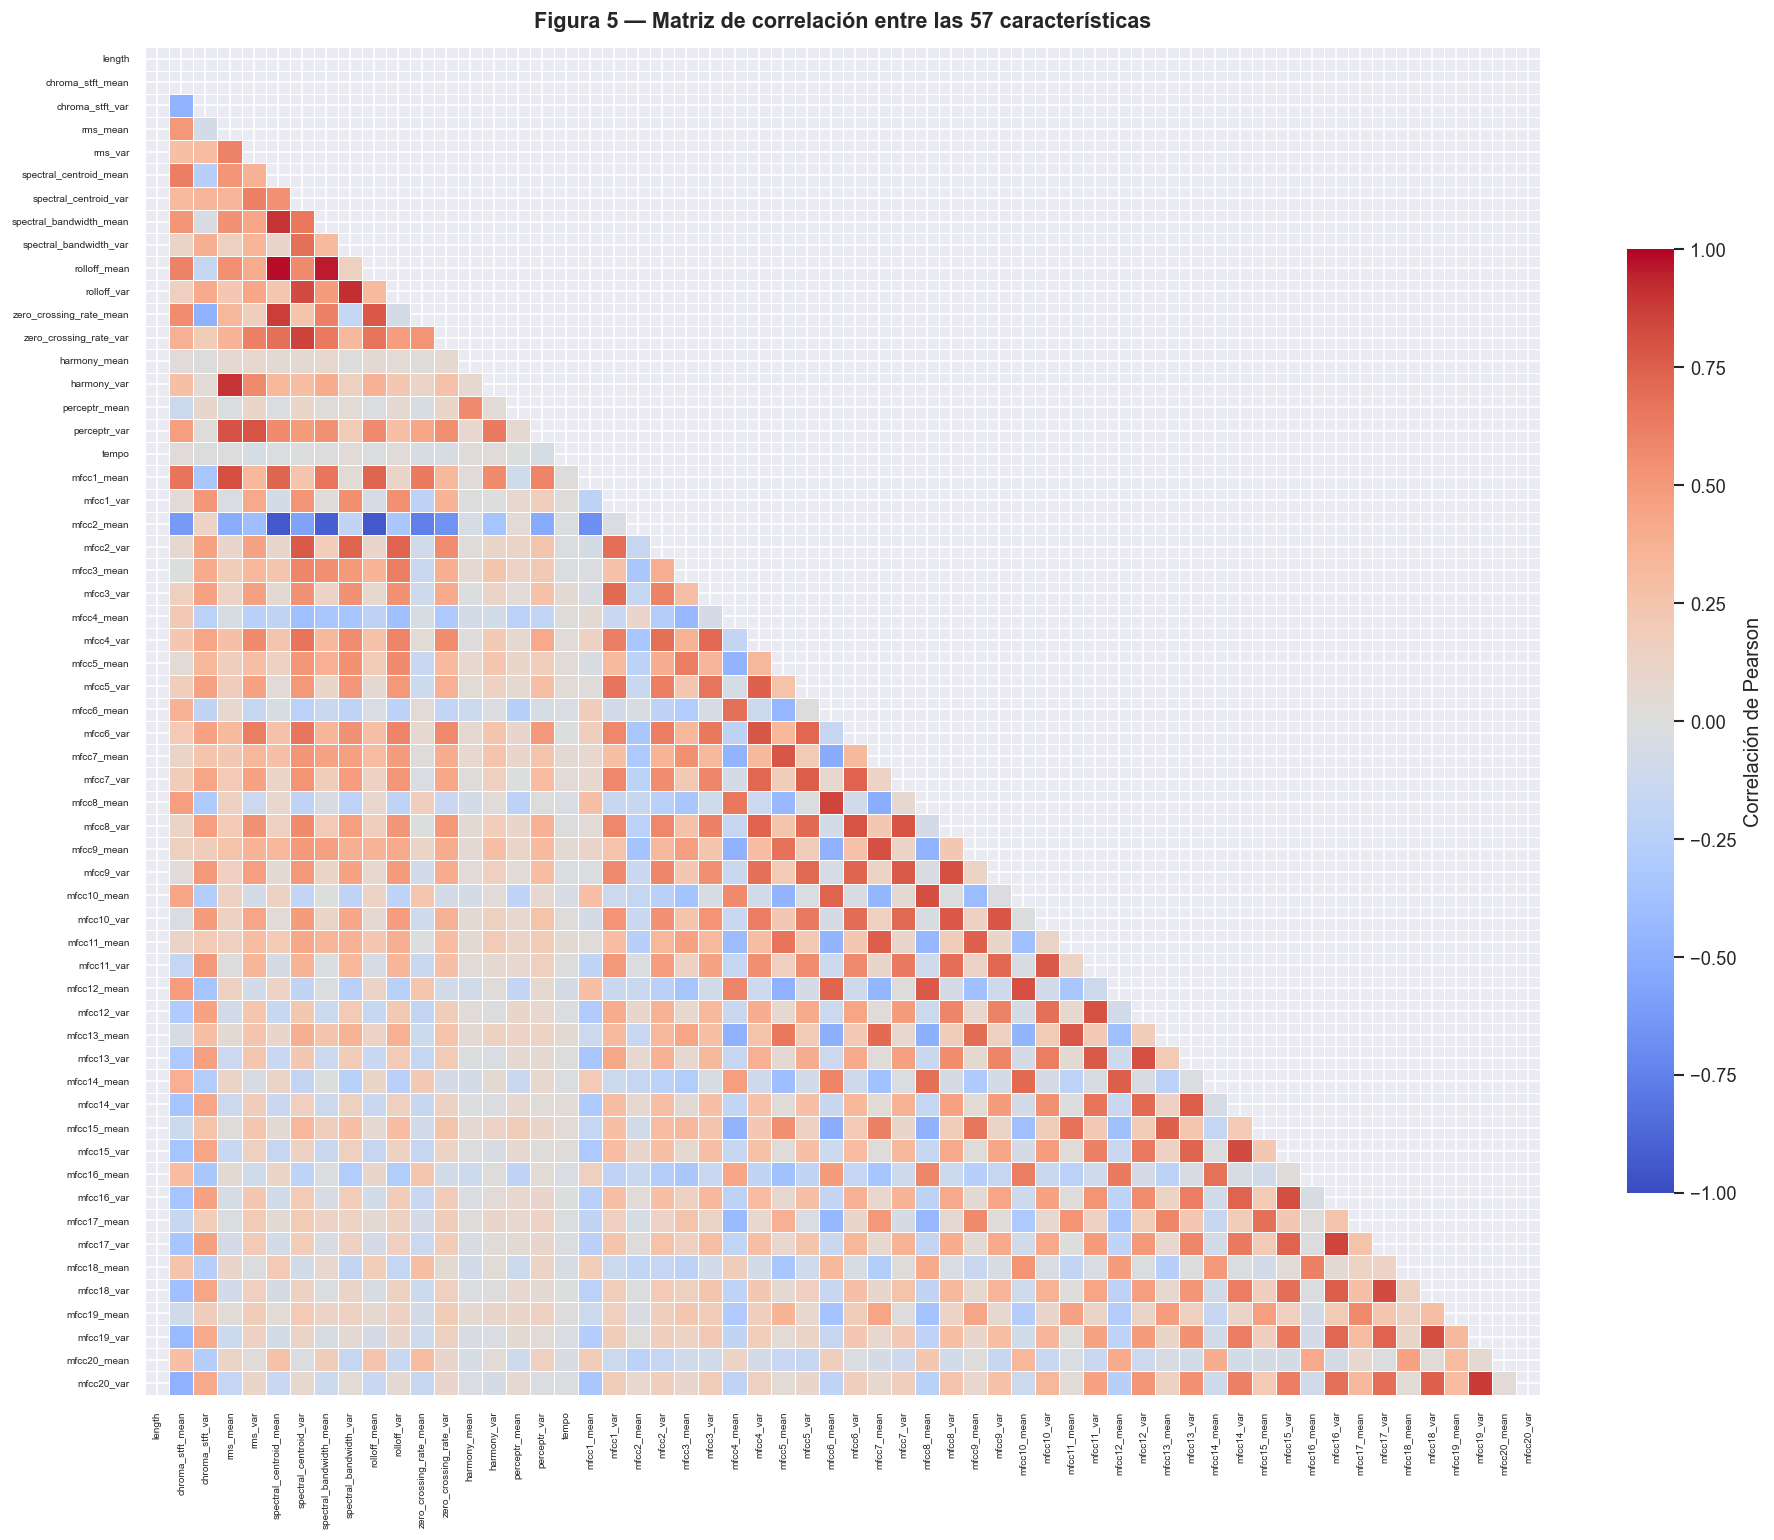

✓ Figura 5 guardada

Top 10 pares más correlacionados:
rolloff_mean            spectral_centroid_mean     0.980
                        spectral_bandwidth_mean    0.957
mfcc2_mean              spectral_centroid_mean     0.942
                        rolloff_mean               0.939
rolloff_var             spectral_bandwidth_var     0.919
mfcc2_mean              spectral_bandwidth_mean    0.906
spectral_centroid_mean  spectral_bandwidth_mean    0.906
harmony_var             rms_mean                   0.900
mfcc19_var              mfcc20_var                 0.877
spectral_centroid_mean  zero_crossing_rate_mean    0.874
dtype: float64


In [8]:
corr_matrix = df_songs[feat_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            vmin=-1, vmax=1, annot=False, linewidths=0.3,
            cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.7}, ax=ax)
ax.set_title('Figura 5 — Matriz de correlación entre las 57 características',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=6)
plt.tight_layout()
plt.savefig('fig05_correlacion.png', bbox_inches='tight')
plt.show()
print('✓ Figura 5 guardada')

# Top correlaciones
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print('\nTop 10 pares más correlacionados:')
print(corr_pairs.head(10).round(3))

### 3.2 Scatter plots: pares de características clave

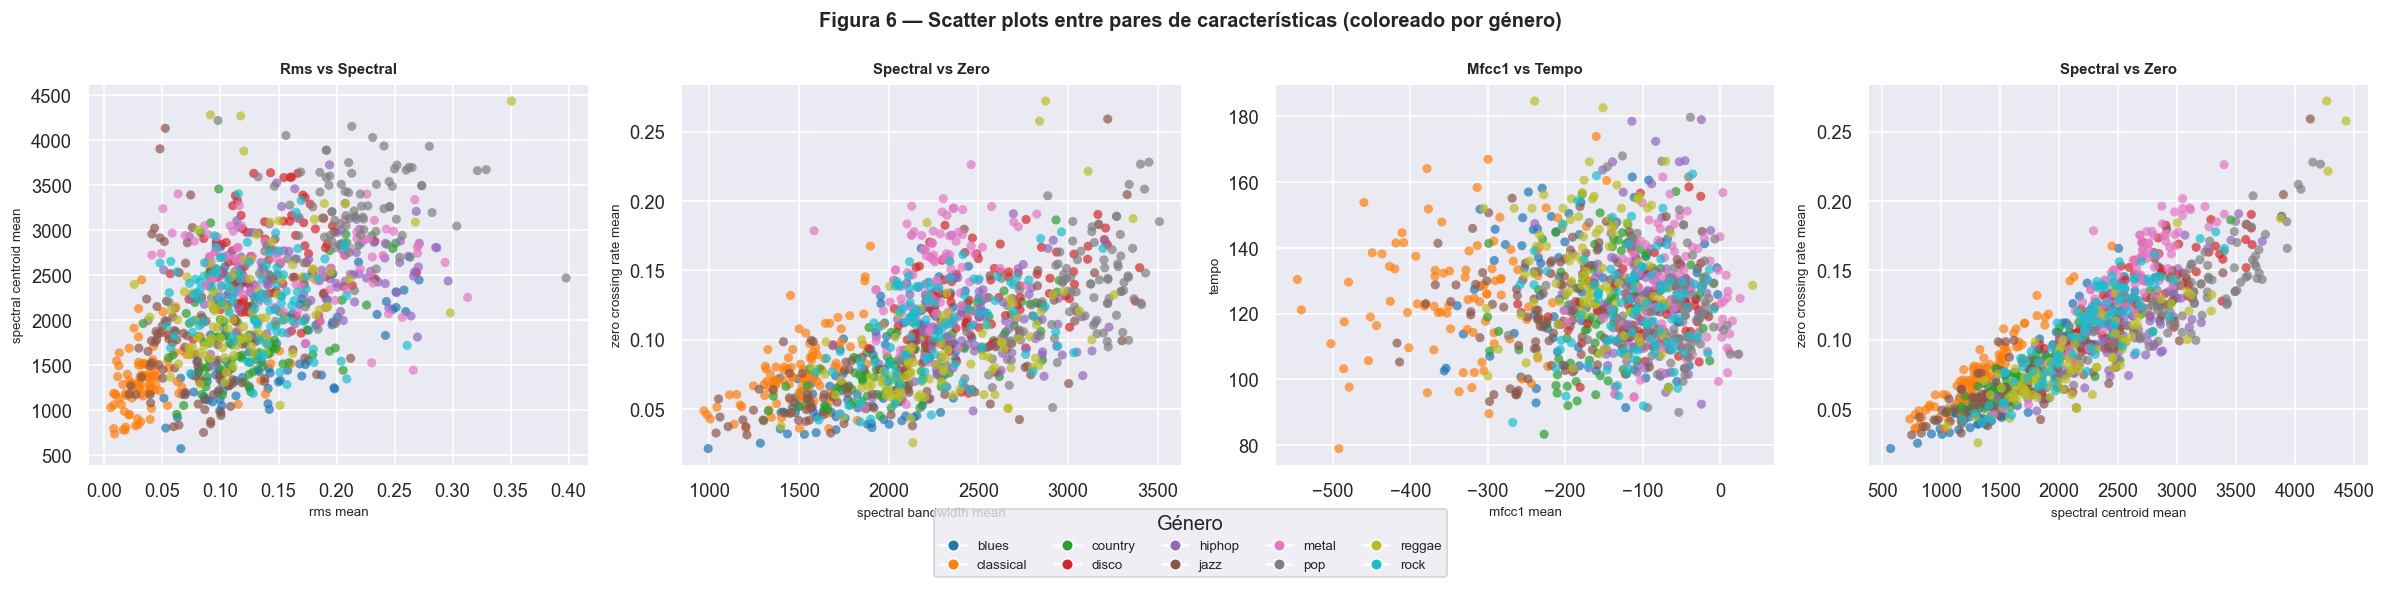

✓ Figura 6 guardada


In [9]:
# Seleccionamos 4 pares interesantes
pairs = []
c = list(available.values())
if len(c) >= 2: pairs.append((c[0], c[1]))
if len(c) >= 4: pairs.append((c[2], c[3]))
if len(c) >= 6: pairs.append((c[4], c[5]))
# Si hay un par espectral-centroid vs ZCR lo añadimos
sc = available.get('spectral_centroid_mean')
zcr = available.get('zero_crossing_rate_mean')
if sc and zcr: pairs.append((sc, zcr))

n_pairs = min(len(pairs), 4)
fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4.5))
if n_pairs == 1: axes = [axes]

for ax, (cx, cy) in zip(axes, pairs[:n_pairs]):
    for genre in GENEROS:
        sub = df_songs[df_songs['genre'] == genre]
        ax.scatter(sub[cx], sub[cy], label=genre, color=GENRE_COLOR[genre],
                   s=30, alpha=0.7, edgecolors='none')
    ax.set_xlabel(cx.replace('_', ' '), fontsize=8)
    ax.set_ylabel(cy.replace('_', ' '), fontsize=8)
    ax.set_title(f'{cx.split("_")[0].title()} vs {cy.split("_")[0].title()}', fontsize=9, fontweight='bold')

handles = [plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=GENRE_COLOR[g],
           markersize=7, label=g) for g in GENEROS]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.08), title='Género')
fig.suptitle('Figura 6 — Scatter plots entre pares de características (coloreado por género)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig06_scatter.png', bbox_inches='tight')
plt.show()
print('✓ Figura 6 guardada')

### 3.3 Heatmap de medias por género (perfil acústico)

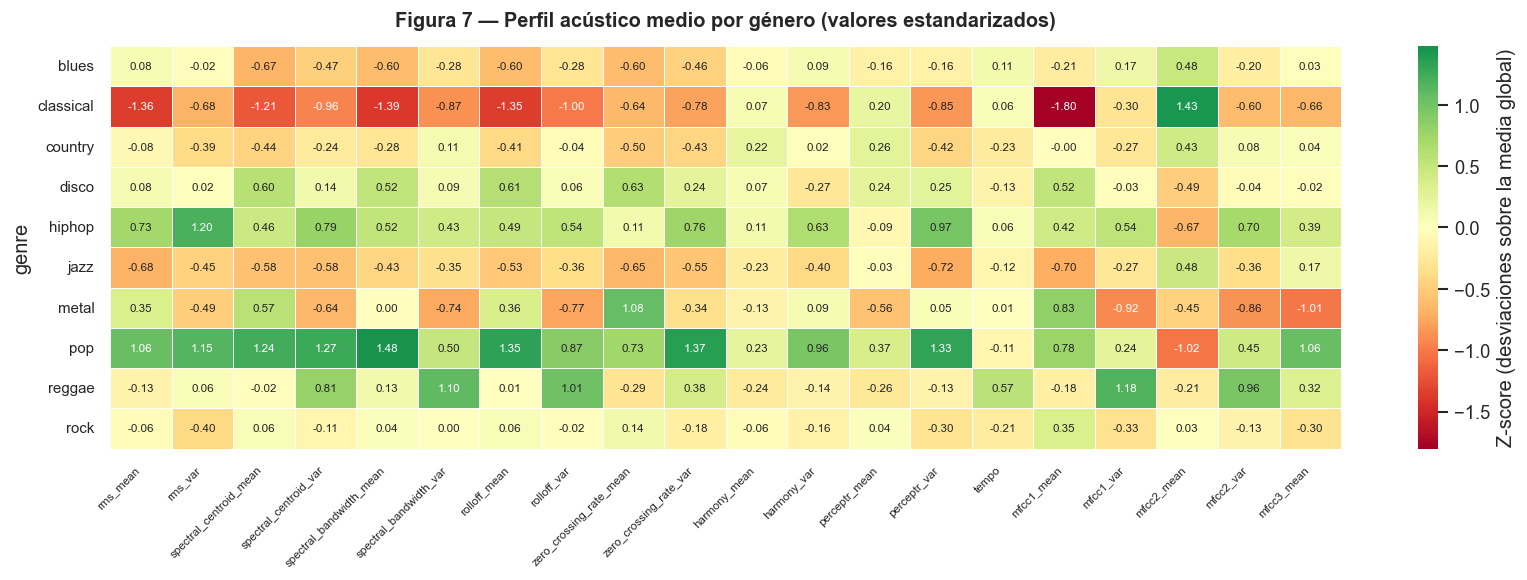

✓ Figura 7 guardada


In [12]:
# Normalizamos para que todos los valores sean comparables
scaler = StandardScaler()
df_scaled = df_songs.copy()
df_scaled[feat_cols] = scaler.fit_transform(df_songs[feat_cols])

# Media por género (valores estandarizados)
genre_means = df_scaled.groupby('genre')[feat_cols].mean()

# Seleccionamos un subconjunto representativo de características
key_subset = [c for c in feat_cols if any(k in c.lower() for k in
              ['tempo','rms','centroid','bandwidth','rolloff','zero','harmony','perceptr','mfcc1','mfcc2','mfcc3'])]
key_subset = key_subset[:20]  # máximo 20

fig, ax = plt.subplots(figsize=(14, 5))

# --- CÓDIGO CORREGIDO ABAJO ---
sns.heatmap(genre_means[key_subset].reindex(GENEROS),
            cmap='RdYlGn', center=0, annot=True, fmt='.2f', 
            annot_kws={'fontsize': 7},  # <--- Cambio aquí
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Z-score (desviaciones sobre la media global)'})

ax.set_title('Figura 7 — Perfil acústico medio por género (valores estandarizados)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)

plt.tight_layout()
plt.savefig('fig07_heatmap_generos.png', bbox_inches='tight')
plt.show()
print('✓ Figura 7 guardada')

### 3.4 Reducción de dimensionalidad: PCA

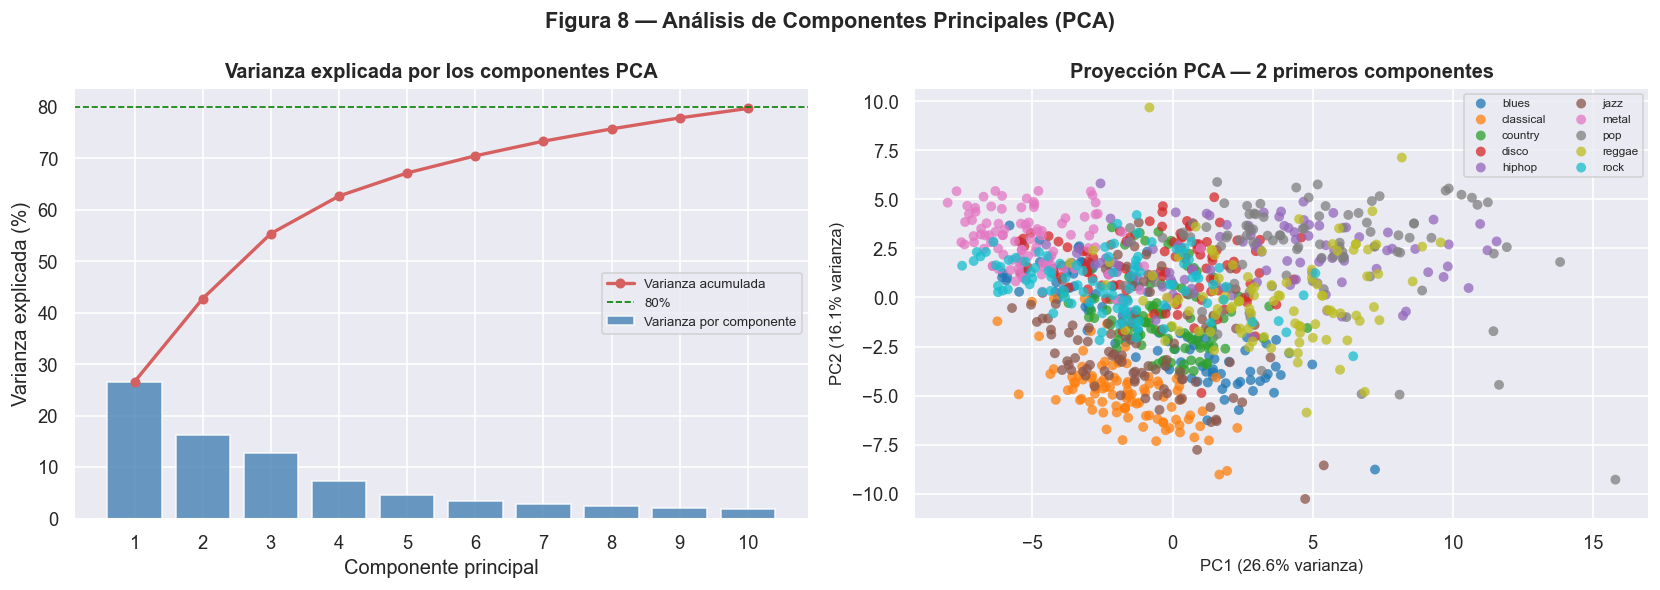

✓ Figura 8 guardada
PC1 + PC2 explican: 42.8% de la varianza total
Varianza acumulada en 5 componentes: 67.2%


In [13]:
X = df_scaled[feat_cols].values
y_genre = df_scaled['genre'].values

pca = PCA(n_components=min(10, len(feat_cols)))
X_pca = pca.fit_transform(X)

# Varianza explicada
var_exp = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: Varianza explicada acumulada
ax = axes[0]
ax.bar(range(1, len(var_exp)+1), var_exp, color='steelblue', alpha=0.8, label='Varianza por componente')
ax.plot(range(1, len(var_exp)+1), np.cumsum(var_exp), 'ro-', linewidth=2, markersize=5, label='Varianza acumulada')
ax.axhline(80, color='green', linestyle='--', linewidth=1, label='80%')
ax.set_xlabel('Componente principal'); ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Varianza explicada por los componentes PCA', fontweight='bold')
ax.legend(fontsize=8)
ax.set_xticks(range(1, len(var_exp)+1))

# ── Plot 2: Proyección en PC1–PC2
ax2 = axes[1]
for genre in GENEROS:
    mask = y_genre == genre
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=genre, color=GENRE_COLOR[genre], s=35, alpha=0.75, edgecolors='none')
ax2.set_xlabel(f'PC1 ({var_exp[0]:.1f}% varianza)', fontsize=10)
ax2.set_ylabel(f'PC2 ({var_exp[1]:.1f}% varianza)', fontsize=10)
ax2.set_title('Proyección PCA — 2 primeros componentes', fontweight='bold')
ax2.legend(fontsize=7, ncol=2, loc='upper right')

fig.suptitle('Figura 8 — Análisis de Componentes Principales (PCA)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig08_pca.png', bbox_inches='tight')
plt.show()
print(f'✓ Figura 8 guardada')
print(f'PC1 + PC2 explican: {var_exp[0]+var_exp[1]:.1f}% de la varianza total')
print(f'Varianza acumulada en 5 componentes: {sum(var_exp[:5]):.1f}%')

---
## 4. Evaluación de supuestos
### 4.1 Test de normalidad (Shapiro-Wilk)

In [14]:
resultados_shapiro = []
for col in feat_cols:
    stat, p = stats.shapiro(df_songs[col].dropna())
    resultados_shapiro.append({'característica': col, 'estadístico_W': round(stat, 4),
                               'p_valor': round(p, 4), 'normal (p>0.05)': p > 0.05})

df_shapiro = pd.DataFrame(resultados_shapiro)
normales = df_shapiro['normal (p>0.05)'].sum()
no_normales = len(df_shapiro) - normales
print(f'Características con distribución normal: {normales}/{len(df_shapiro)}')
print(f'Características NO normales: {no_normales}/{len(df_shapiro)}')
print('\nPrimeros 15 resultados:')
display(df_shapiro.head(15))

Características con distribución normal: 3/58
Características NO normales: 55/58

Primeros 15 resultados:


,característica,estadístico_W,p_valor,normal (p>0.05)
0,length,1.0000,1.0000,True
1,chroma_stft_mean,0.9925,0.0001,False
2,chroma_stft_var,0.9531,0.0000,False
3,rms_mean,0.9812,0.0000,False
4,rms_var,0.6826,0.0000,False
5,spectral_centroid_mean,0.9896,0.0000,False
6,spectral_centroid_var,0.8435,0.0000,False
7,spectral_bandwidth_mean,0.9903,0.0000,False
8,spectral_bandwidth_var,0.8877,0.0000,False
9,rolloff_mean,0.9914,0.0000,False


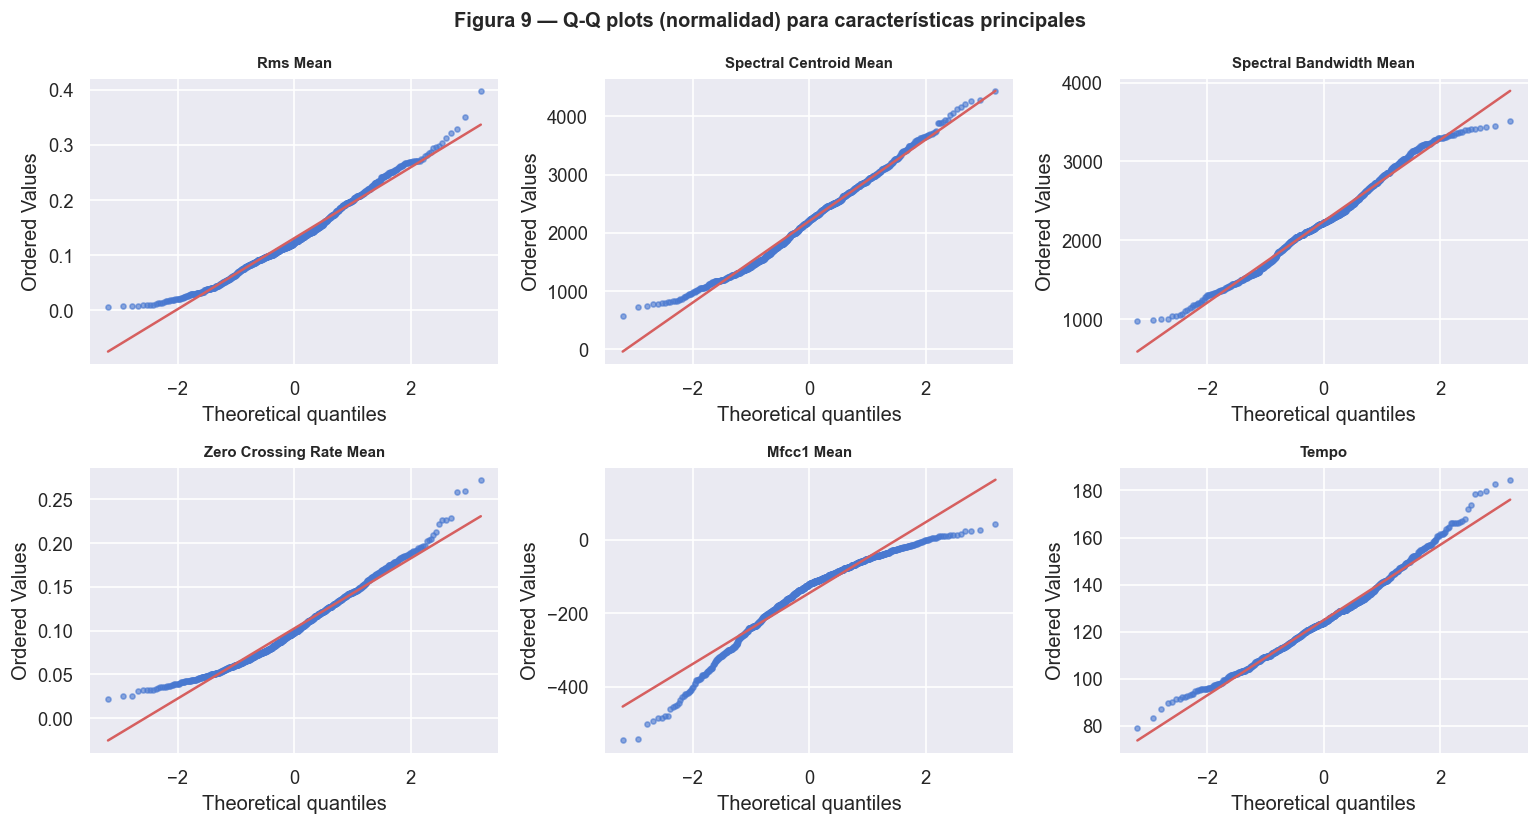

✓ Figura 9 guardada


In [15]:
# Q-Q plots para las 6 características clave
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()
for i, col in enumerate(selected[:6]):
    ax = axes[i]
    stats.probplot(df_songs[col].dropna(), dist='norm', plot=ax)
    ax.set_title(col.replace('_', ' ').title(), fontsize=9, fontweight='bold')
    ax.get_lines()[0].set(markersize=3, alpha=0.6)

fig.suptitle('Figura 9 — Q-Q plots (normalidad) para características principales',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig09_qqplots.png', bbox_inches='tight')
plt.show()
print('✓ Figura 9 guardada')

---
## 5. Detección de atípicos
### 5.1 Método IQR y Z-score modificado (MAD)

In [16]:
def detectar_outliers_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return ((serie < Q1 - 1.5*IQR) | (serie > Q3 + 1.5*IQR)).sum()

def detectar_outliers_mad(serie, umbral=3.5):
    med = serie.median()
    mad = np.median(np.abs(serie - med))
    if mad == 0: return 0
    z_mod = 0.6745 * (serie - med) / mad
    return (np.abs(z_mod) > umbral).sum()

outlier_stats = pd.DataFrame({
    'Outliers IQR': [detectar_outliers_iqr(df_songs[c]) for c in feat_cols],
    'Outliers MAD': [detectar_outliers_mad(df_songs[c]) for c in feat_cols],
}, index=feat_cols)
outlier_stats['% IQR'] = (outlier_stats['Outliers IQR'] / len(df_songs) * 100).round(1)
outlier_stats_sorted = outlier_stats.sort_values('Outliers IQR', ascending=False)
print('Top 10 características con más outliers (IQR):')
display(outlier_stats_sorted.head(10))
print(f'\nTotal outliers únicos (IQR): {outlier_stats["Outliers IQR"].sum()} sobre {len(df_songs)*len(feat_cols)} valores')

Top 10 características con más outliers (IQR):


,Outliers IQR,Outliers MAD,% IQR
harmony_mean,236,289,23.6
perceptr_mean,159,296,15.9
rms_var,89,82,8.9
zero_crossing_rate_var,76,66,7.6
perceptr_var,66,65,6.6
spectral_centroid_var,50,36,5.0
mfcc20_var,46,33,4.6
harmony_var,45,45,4.5
rolloff_var,40,25,4.0
mfcc16_var,39,25,3.9



Total outliers únicos (IQR): 1584 sobre 58000 valores


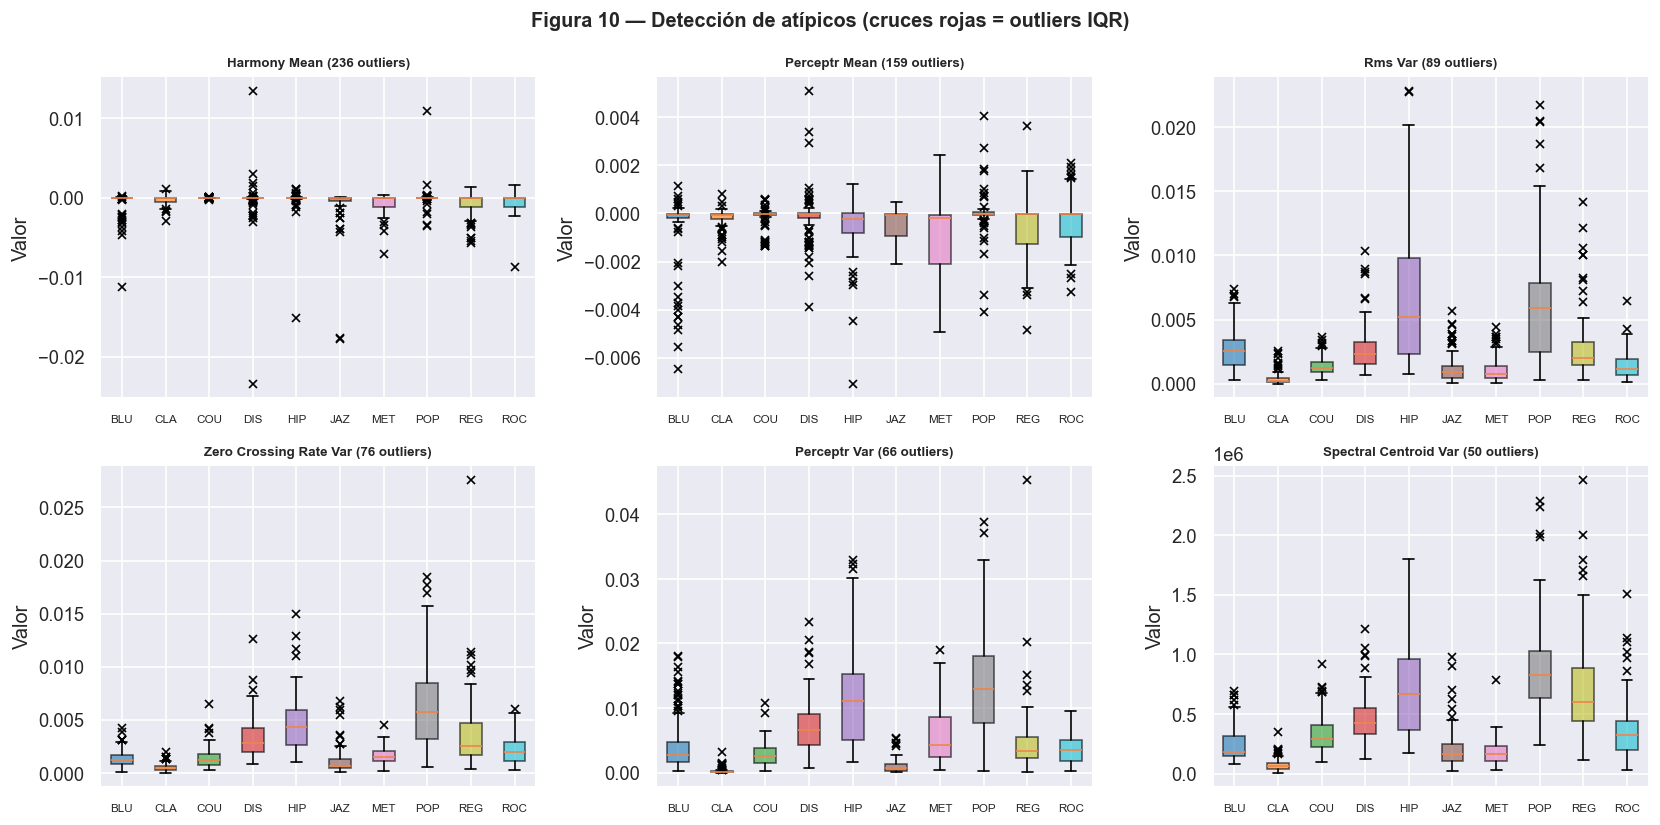

✓ Figura 10 guardada


In [17]:
# Visualización de outliers en las características con más
top_outlier_cols = outlier_stats_sorted.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(top_outlier_cols):
    ax = axes[i]
    data_by_genre = [df_songs[df_songs['genre'] == g][col].values for g in GENEROS]
    bp = ax.boxplot(data_by_genre, patch_artist=True, flierprops=dict(marker='x', color='red', markersize=5))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color); patch.set_alpha(0.6)
    ax.set_xticklabels([g[:3].upper() for g in GENEROS], fontsize=7)
    ax.set_title(f'{col.replace("_"," ").title()} ({outlier_stats.loc[col,"Outliers IQR"]} outliers)',
                 fontsize=8, fontweight='bold')
    ax.set_ylabel('Valor')

fig.suptitle('Figura 10 — Detección de atípicos (cruces rojas = outliers IQR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig10_outliers.png', bbox_inches='tight')
plt.show()
print('✓ Figura 10 guardada')

### 5.2 Outliers multivariantes (distancia de Mahalanobis en espacio PCA)

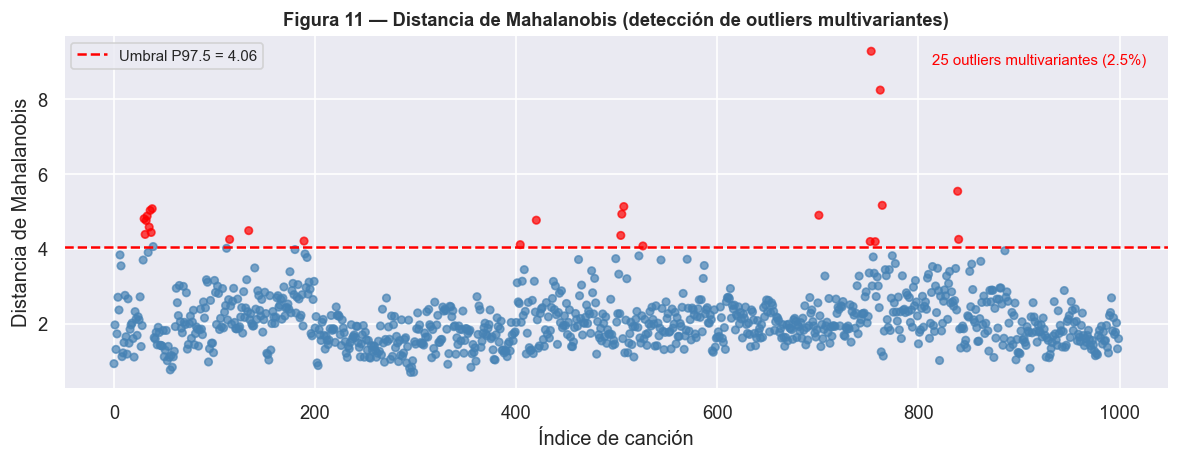

✓ Figura 11 guardada  |  Outliers multivariantes: 25


In [18]:
from scipy.spatial.distance import mahalanobis

X_pca2 = X_pca[:, :5]  # Usamos los 5 primeros componentes
cov = np.cov(X_pca2.T)
cov_inv = np.linalg.pinv(cov)
mean_vec = X_pca2.mean(axis=0)
dist_mah = np.array([mahalanobis(row, mean_vec, cov_inv) for row in X_pca2])

umbral_mah = np.percentile(dist_mah, 97.5)  # Top 2.5%
n_outliers_mah = (dist_mah > umbral_mah).sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(dist_mah)), dist_mah,
           c=['red' if d > umbral_mah else 'steelblue' for d in dist_mah],
           s=20, alpha=0.7)
ax.axhline(umbral_mah, color='red', linestyle='--', linewidth=1.5, label=f'Umbral P97.5 = {umbral_mah:.2f}')
ax.set_title('Figura 11 — Distancia de Mahalanobis (detección de outliers multivariantes)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Índice de canción'); ax.set_ylabel('Distancia de Mahalanobis')
ax.legend(fontsize=9)
ax.text(0.98, 0.95, f'{n_outliers_mah} outliers multivariantes ({n_outliers_mah/len(dist_mah)*100:.1f}%)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='red')
plt.tight_layout()
plt.savefig('fig11_mahalanobis.png', bbox_inches='tight')
plt.show()
print(f'✓ Figura 11 guardada  |  Outliers multivariantes: {n_outliers_mah}')

---
## 6. Tratamiento de ausentes
### 6.1 Mapa de valores nulos

=== Valores nulos en el dataset original (fragmentos de 3s) ===
✓ Ningún valor nulo en el CSV original

=== Valores nulos en el dataset agrupado por canción ===
✓ Ningún valor nulo tras agrupar


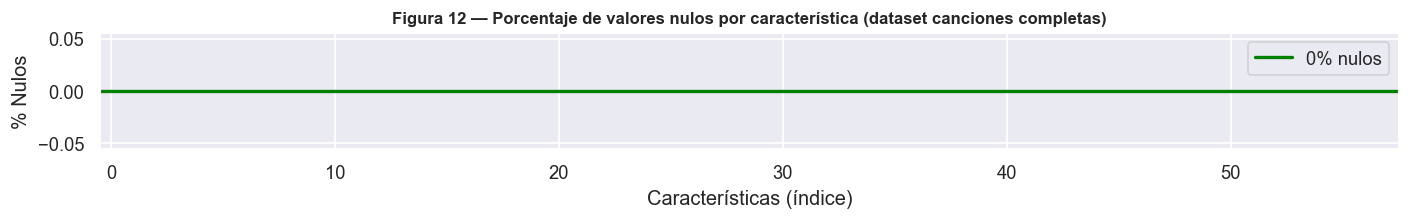

✓ Figura 12 guardada


In [19]:
nulls_raw = df_raw[feat_cols].isnull().sum()
nulls_songs = df_songs[feat_cols].isnull().sum()

print('=== Valores nulos en el dataset original (fragmentos de 3s) ===')
print(nulls_raw[nulls_raw > 0] if nulls_raw.any() else '✓ Ningún valor nulo en el CSV original')
print('\n=== Valores nulos en el dataset agrupado por canción ===')
print(nulls_songs[nulls_songs > 0] if nulls_songs.any() else '✓ Ningún valor nulo tras agrupar')

fig, ax = plt.subplots(figsize=(12, 2))
null_pct = df_songs[feat_cols].isnull().mean() * 100
ax.bar(range(len(null_pct)), null_pct.values, color='steelblue', alpha=0.8)
ax.axhline(0, color='green', linewidth=2, label='0% nulos')
ax.set_xlim(-0.5, len(null_pct) - 0.5)
ax.set_title('Figura 12 — Porcentaje de valores nulos por característica (dataset canciones completas)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Características (índice)'); ax.set_ylabel('% Nulos')
ax.legend()
plt.tight_layout()
plt.savefig('fig12_nulos.png', bbox_inches='tight')
plt.show()
print('✓ Figura 12 guardada')

---
## 7. Resumen final y conclusiones numéricas

In [20]:
print('=' * 55)
print('  RESUMEN DEL ANÁLISIS EXPLORATORIO — P05 GTZAN')
print('=' * 55)
print(f'  Canciones en el dataset:          {len(df_songs)}')
print(f'  Géneros:                          {df_songs["genre"].nunique()}')
print(f'  Características numéricas:        {len(feat_cols)}')
print(f'  Valores nulos (CSV):               0')
print(f'  Características normales (SW):     {normales}/{len(df_shapiro)}')
print(f'  Outliers multivariantes (P97.5):  {n_outliers_mah} ({n_outliers_mah/len(df_songs)*100:.1f}%)')
print(f'  Varianza explicada PC1+PC2:        {var_exp[0]+var_exp[1]:.1f}%')
print(f'  Varianza explicada en 5 PCs:       {sum(var_exp[:5]):.1f}%')
if tempo_col:
    print(f'  Tempo medio:                       {df_songs[tempo_col].mean():.0f} BPM')
    print(f'  Tempo rango:                       {df_songs[tempo_col].min():.0f}–{df_songs[tempo_col].max():.0f} BPM')
print('=' * 55)
print()
print('Figuras generadas:')
for i, nombre in enumerate([
    'fig01_distribucion_generos.png',
    'fig02_histogramas.png',
    'fig03_boxplots.png',
    'fig04_tempo.png',
    'fig05_correlacion.png',
    'fig06_scatter.png',
    'fig07_heatmap_generos.png',
    'fig08_pca.png',
    'fig09_qqplots.png',
    'fig10_outliers.png',
    'fig11_mahalanobis.png',
    'fig12_nulos.png',
], 1):
    print(f'  Figura {i:02d}: {nombre}')

  RESUMEN DEL ANÁLISIS EXPLORATORIO — P05 GTZAN
  Canciones en el dataset:          1000
  Géneros:                          10
  Características numéricas:        58
  Valores nulos (CSV):               0
  Características normales (SW):     3/58
  Outliers multivariantes (P97.5):  25 (2.5%)
  Varianza explicada PC1+PC2:        42.8%
  Varianza explicada en 5 PCs:       67.2%
  Tempo medio:                       125 BPM
  Tempo rango:                       79–185 BPM

Figuras generadas:
  Figura 01: fig01_distribucion_generos.png
  Figura 02: fig02_histogramas.png
  Figura 03: fig03_boxplots.png
  Figura 04: fig04_tempo.png
  Figura 05: fig05_correlacion.png
  Figura 06: fig06_scatter.png
  Figura 07: fig07_heatmap_generos.png
  Figura 08: fig08_pca.png
  Figura 09: fig09_qqplots.png
  Figura 10: fig10_outliers.png
  Figura 11: fig11_mahalanobis.png
  Figura 12: fig12_nulos.png
